# QDock-Kaiwu — docking on the Coherent Ising Machine

Molecular docking splits into **pose sampling** (search the binding geometry —
NP-hard) and **scoring** (rank poses — cheap). QDock casts the sampling step as a
**QUBO** and solves it on the **Kaiwu SDK** — the classical simulated annealer and
the real **Coherent Ising Machine (CIM)**. AutoDock Vina scores the poses.

The CIM returns only ~6–10 distinct poses per run and is **high-variance** on these
dense docking QUBOs: the native pose turns up in roughly **one run in four or five**.
So the workshop's recipe is to **pool a handful of runs** — the native pose then
reliably appears. Two small redocking cases, one per encoding:

| demo | encoding | ligand | qubits | best of 5 CIM runs | per-run RMSD spread |
|---|---|---|---|---|---|
| **3f3d** | GPM (grid) | small fragment | 214 | **1.25 Å** | 1.25 – 4.95 Å |
| **3d4z** | FAM (features) | gluco-imidazole | 336 | **1.84 Å** (5 H-bonds) | 1.84 – 4.57 Å |

## 0. Setup

Get a free `user_id` / `sdk_code` from [platform.qboson.com](https://platform.qboson.com)
and export them as `KAIWU_USER_ID` / `KAIWU_SDK_CODE` before launching Jupyter.

In [1]:
import os, sys, itertools, numpy as np, matplotlib.pyplot as plt
%matplotlib inline
os.environ['PATH'] = os.path.expanduser('~/miniforge3/envs/chem/bin') + os.pathsep + os.environ['PATH']
sys.path.insert(0, os.path.abspath('..'))
import kaiwu as kw
from qdock_kaiwu import GPMDock, FAMDock, backends, scoring, evaluate, viz, init_license
from qdock_kaiwu.qubo import build_gpm_qubo, build_fam_qubo
from qdock_kaiwu.gpm import _matches_to_poses
from qdock_kaiwu.params import GPM as GPM_P, FAM as FAM_P

init_license()                                   # reads KAIWU_USER_ID / KAIWU_SDK_CODE
kw.common.CheckpointManager.save_dir = os.path.abspath('../cim_cache')  # reproduces shipped CIM runs
DATA = os.path.abspath('../data')

## 1. A QUBO on Kaiwu — SA and the real CIM

Kaiwu minimizes an **Ising** Hamiltonian and returns **spin** (±1) reads. Convert
QUBO↔Ising with Kaiwu's own routine and map the ancilla-gauged spins back to
binary. **Feed the converter's output straight to `solve` — no manual sign flip:**
Kaiwu's raw `solve` maximizes `sᵀMs`, but `qubo_matrix_to_ising_matrix` bakes in
the sign so the maximizer minimizes the QUBO.

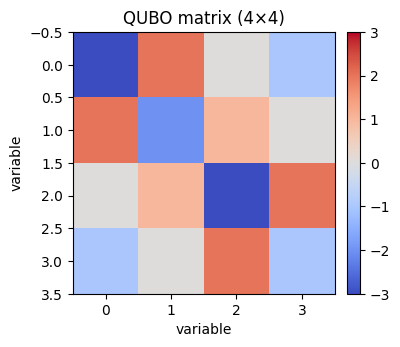

brute-force minimum: -6.0


In [2]:
Q = np.array([[-3.,  2.,  0., -1.],
              [ 0., -2.,  1.,  0.],
              [ 0.,  0., -3.,  2.],
              [ 0.,  0.,  0., -1.]])
brute = min(backends.qubo_energy(Q, np.array(b)) for b in itertools.product([0,1], repeat=4))
fig, ax = plt.subplots(figsize=(4, 3.4)); viz.plot_qubo_matrix(ax, Q); plt.show()
print('brute-force minimum:', brute)

**SA** — `kaiwu.classical.SimulatedAnnealingOptimizer`:

In [3]:
ising, offset = kw.conversion.qubo_matrix_to_ising_matrix(Q)
sa = kw.classical.SimulatedAnnealingOptimizer(initial_temperature=5, alpha=0.99,
         cutoff_temperature=0.01, iterations_per_t=200, size_limit=50, rand_seed=42)
spins = sa.solve(ising)                                  # (reads, n+1) of ±1
ranked = backends._rank_unique([backends._spins_to_binary(s, 4) for s in spins], Q)
print('SA minimum:', ranked[0][0], 'at', ranked[0][1], '| matches brute force:', abs(ranked[0][0]-brute) < 1e-9)

SA minimum: -6.0 at [1 0 1 1] | matches brute force: True


**CIM** — the same Ising matrix on the photonic machine
(`kaiwu.cim.CIMOptimizer`). A submission takes ~1 minute and uses quota; the
shipped cache returns it instantly.

In [4]:
cim = kw.cim.CIMOptimizer(task_name='qdock_workshop_demo', wait=True,
                          interval=1, task_mode='quota', sample_number=10)
spins_cim = np.asarray(cim.solve(ising))
ranked_cim = backends._rank_unique([backends._spins_to_binary(s, 4) for s in spins_cim], Q)
print('CIM minimum:', ranked_cim[0][0], 'at', ranked_cim[0][1], '| matches brute force:', abs(ranked_cim[0][0]-brute) < 1e-9)

[2026-06-23 03:30:17] [INFO    ] [kaiwu.cim._optimizer_adapter:3] - Task calculation successful!, Task name: qdock_workshop_demo


CIM minimum: -6.0 at [1 0 1 0] | matches brute force: True


## 2. Docking as a QUBO

One binary variable per candidate match `x_(a,s) = 1` ⇔ *ligand atom a sits at
site s*. The Hamiltonian rewards a chemically good placement (linear term),
penalizes matches that distort the rigid ligand (`K_dist`), and forbids one atom
in two sites (`K_mono`). Minimizing it selects a consistent set of matches;
superposing matched atoms onto their sites gives a 3-D pose. Two encodings differ
only in what the **sites** are:

- **GPM** — a grid filling the pocket (2.0 Å); reward = van der Waals energy (AutoGrid).
- **FAM** — a few typed pocket **feature atoms** (1.0 Å); reward = electronegativity match.

The CIM is an 8-bit machine, so the QUBO reaches it through a `PrecisionReducer`
that quantizes the matrix (`truncated_precision=12` splits a variable across spins
to keep 12 bits). The solve is the same three lines every time:

In [5]:
def cim_dock(Q, task_name, t=12, samples=300):
    """Solve a docking QUBO on the CIM at precision=8, truncated_precision=t."""
    ising, _ = kw.conversion.qubo_matrix_to_ising_matrix(Q)
    cim = kw.cim.CIMOptimizer(task_name=task_name, wait=True, interval=1,
                              task_mode='quota', sample_number=samples)
    reducer = kw.cim.PrecisionReducer(cim, precision=8, truncated_precision=t,
                                      only_feasible_solution=False)
    spins = np.asarray(reducer.solve(ising))            # quantize → submit → decode
    return backends._rank_unique([backends._spins_to_binary(s, Q.shape[0]) for s in spins], Q)

def pool_runs(Q, lig, variables, sites, receptor_pdbqt, tasks, wd):
    """Run the CIM once per task name, score every pose with Vina, and return the
    per-run best-RMSD plus the single best pose across all runs."""
    per_run, best = [], (9.9, None)
    for task in tasks:
        ranked = cim_dock(Q, task)
        poses, _ = _matches_to_poses(lig, np.array(variables), sites, ranked)
        P = np.array(poses); rmsd = evaluate.pose_rmsds(P, lig.coords, lig.elements)
        vina = scoring.score_poses(receptor_pdbqt, lig.lines, P, wd)
        bi = int(np.nanargmin(vina))
        per_run.append(float(rmsd[bi]))
        if rmsd[bi] < best[0]: best = (float(rmsd[bi]), P[bi])
    return per_run, best

## 3. GPM demo — 3f3d, pooling CIM runs

Fill the pocket with a 2.0 Å grid; AutoGrid gives each point a van der Waals
energy. 214 variables — small, so even at `t=12` the precision-expanded matrix
stays under the machine's ~1000-spin budget.

In [6]:
g = GPMDock(backend='cim', workdir='nb_gpm')
g.make_receptor(f'{DATA}/3f3d_protein.mol2')
g.make_ligand([f'{DATA}/3f3d_ligand.mol2'])
g.make_box_ligand(f'{DATA}/3f3d_ligand.mol2')          # 2.0 Å grid (GPM default)
lig = g.ligands[0]
Qg, vars_g = build_gpm_qubo(lig.coords, lig.ad_types, g.grid_dict, g.box_coords,
                            GPM_P['edge_cutoff'], GPM_P['K_dist'], GPM_P['K_mono'])
print('GPM QUBO variables:', Qg.shape[0])

GPM QUBO variables: 214


Favourable grid points (blue) around the ligand (black):

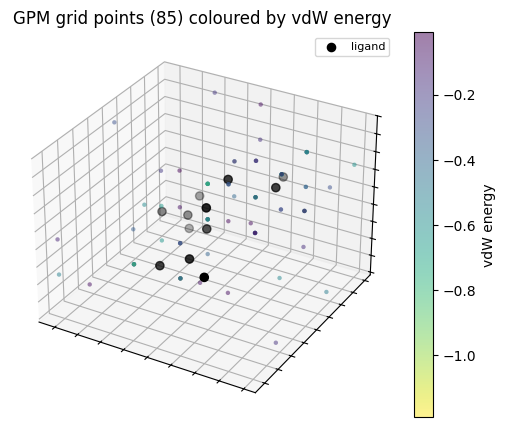

In [7]:
gpts = np.vstack([g.box_coords[g.grid_dict[t][0]] for t in g.grid_dict if len(g.grid_dict[t][0])])
gen  = np.concatenate([g.grid_dict[t][1] for t in g.grid_dict if len(g.grid_dict[t][0])])
fig = plt.figure(figsize=(6, 5)); ax = fig.add_subplot(111, projection='3d')
viz.plot_grid_sites(ax, gpts, gen, lig.coords); plt.show()

**Pool five CIM runs.** Each is an independent draw; the best-RMSD pose per run
swings widely (sampling-limited), but the pool reliably contains the native pose:

In [8]:
runs_g = ['qdock_3f3d_GPM_2p0_p8t12'] + [f'repro3_3f3d_GPM_t12_r{i}' for i in range(4)]
per_run_g, (best_rmsd_g, best_pose_g) = pool_runs(Qg, lig, vars_g, g.box_coords, g.receptor_pdbqt, runs_g, 'nb_gpm/score')
print('per-run best RMSD:', [round(x,2) for x in per_run_g])
print(f'pooled best: {best_rmsd_g:.2f} Å')

[2026-06-23 03:30:18] [INFO    ] [kaiwu.cim._optimizer_adapter:8] - Task calculation successful!, Task name: qdock_3f3d_GPM_2p0_p8t12


[2026-06-23 03:30:21] [INFO    ] [kaiwu.cim._optimizer_adapter:8] - Task calculation successful!, Task name: repro3_3f3d_GPM_t12_r0


[2026-06-23 03:30:25] [INFO    ] [kaiwu.cim._optimizer_adapter:8] - Task calculation successful!, Task name: repro3_3f3d_GPM_t12_r1


[2026-06-23 03:30:29] [INFO    ] [kaiwu.cim._optimizer_adapter:8] - Task calculation successful!, Task name: repro3_3f3d_GPM_t12_r2


[2026-06-23 03:30:32] [INFO    ] [kaiwu.cim._optimizer_adapter:8] - Task calculation successful!, Task name: repro3_3f3d_GPM_t12_r3


per-run best RMSD: [1.25, 3.05, 4.58, 4.46, 4.95]
pooled best: 1.25 Å


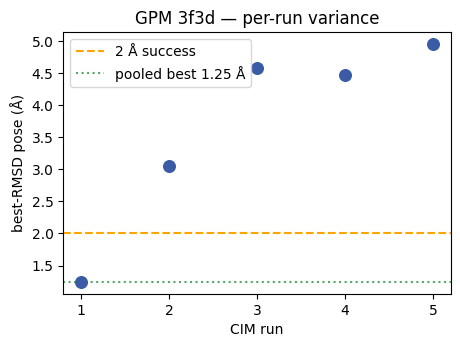

In [9]:
fig, ax = plt.subplots(figsize=(5, 3.4))
ax.scatter(range(1, len(per_run_g)+1), per_run_g, s=70, color='#3B5BA5', zorder=3)
ax.axhline(2.0, ls='--', color='orange', label='2 Å success'); ax.axhline(best_rmsd_g, ls=':', color='#55A868', label=f'pooled best {best_rmsd_g:.2f} Å')
ax.set_xlabel('CIM run'); ax.set_ylabel('best-RMSD pose (Å)'); ax.set_xticks(range(1, len(per_run_g)+1))
ax.set_title('GPM 3f3d — per-run variance'); ax.legend(); plt.show()

The pooled-best pose vs the crystal, scored by Vina:

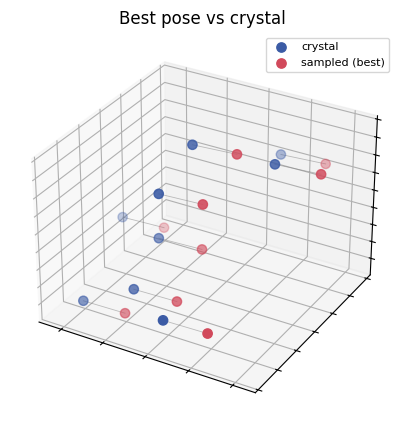

Vina: pooled-best pose 3.17  vs  crystal -6.62 kcal/mol


In [10]:
fig = plt.figure(figsize=(6, 5)); ax = fig.add_subplot(111, projection='3d')
viz.plot_pose_overlay(ax, best_pose_g, lig.coords, lig.elements); plt.show()
vb = scoring.score_pose(g.receptor_pdbqt, lig.lines, best_pose_g, 'nb_gpm/score', 'best')
vc = scoring.score_pose(g.receptor_pdbqt, lig.lines, lig.coords,   'nb_gpm/score', 'cryst')
print(f'Vina: pooled-best pose {vb:.2f}  vs  crystal {vc:.2f} kcal/mol')

## 4. FAM demo — 3d4z, read out as hydrogen bonds

3d4z is Golgi mannosidase II with **gluco-imidazole**, an iminosugar whose
recognition is all hydrogen bonds (2 N + 4 O). FAM rewards matching each ligand
atom to a pocket feature of similar electronegativity — polar to polar — so it is
the natural encoding for an H-bonded ligand. We cap the pocket at **24 feature
atoms** so the precision-expanded matrix stays under 1000 spins.

In [11]:
f = FAMDock(backend='cim', workdir='nb_fam', max_features=24)
f.make_receptor(f'{DATA}/3d4z_protein.pdb')
f.make_ligand([f'{DATA}/3d4z_ligand.mol2'])
f.make_box_ligand(f'{DATA}/3d4z_ligand.mol2')          # 1.0 Å (FAM default)
ligf = f.ligands[0]
Qf, vars_f = build_fam_qubo(ligf.coords, ligf.ad_types, f.feat_coords, f.feat_elements,
                            FAM_P['edge_cutoff'], FAM_P['K_dist'], FAM_P['K_mono'])
print('FAM QUBO variables:', Qf.shape[0], '| feature atoms:', len(f.feat_coords))

FAM QUBO variables: 336 | feature atoms: 24


Typed pocket feature atoms (N = blue, O = red) — a handful, vs hundreds of grid points:

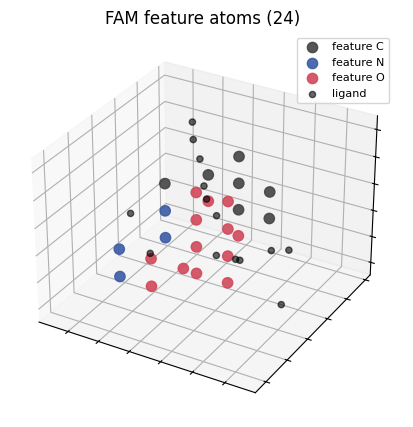

In [12]:
fig = plt.figure(figsize=(6, 5)); ax = fig.add_subplot(111, projection='3d')
viz.plot_feature_sites(ax, f.feat_coords, f.feat_elements, ligf.coords); plt.show()

Same five-run pool:

In [13]:
runs_f = ['qdock_3d4z_FAM_1p0_p8t12'] + [f'repro3_3d4z_FAM_t12_r{i}' for i in range(4)]
per_run_f, (best_rmsd_f, best_pose_f) = pool_runs(Qf, ligf, vars_f, f.feat_coords, f.receptor_pdbqt, runs_f, 'nb_fam/score')
print('per-run best RMSD:', [round(x,2) for x in per_run_f])
print(f'pooled best: {best_rmsd_f:.2f} Å')

[2026-06-23 03:30:38] [INFO    ] [kaiwu.cim._optimizer_adapter:8] - Task calculation successful!, Task name: qdock_3d4z_FAM_1p0_p8t12


[2026-06-23 03:30:42] [INFO    ] [kaiwu.cim._optimizer_adapter:8] - Task calculation successful!, Task name: repro3_3d4z_FAM_t12_r0


[2026-06-23 03:30:45] [INFO    ] [kaiwu.cim._optimizer_adapter:8] - Task calculation successful!, Task name: repro3_3d4z_FAM_t12_r1


[2026-06-23 03:30:47] [INFO    ] [kaiwu.cim._optimizer_adapter:8] - Task calculation successful!, Task name: repro3_3d4z_FAM_t12_r2


[2026-06-23 03:30:49] [INFO    ] [kaiwu.cim._optimizer_adapter:8] - Task calculation successful!, Task name: repro3_3d4z_FAM_t12_r3


per-run best RMSD: [1.84, 2.7, 4.57, 3.82, 4.37]
pooled best: 1.84 Å


**The hydrogen-bond read-out.** List every ligand N/O in the pooled-best pose
that lands within 3.5 Å of a receptor N/O — the polar contacts the encoding was
built to find. The docked pose recovers the crystal's hydrogen bonds:

In [14]:
def polar_contacts(xyz, el, rec_xyz, rec_el, cut=3.5):
    el = np.array([str(e).strip().upper()[:1] for e in el])
    rec_el = np.array([str(e).strip().upper()[:1] for e in rec_el])
    R = np.asarray(rec_xyz)[np.isin(rec_el, ['N','O'])]
    return [(el[i], i, round(float(np.linalg.norm(R - xyz[i], axis=1).min()), 2))
            for i in np.where(np.isin(el, ['N','O']))[0]
            if np.linalg.norm(R - xyz[i], axis=1).min() <= cut]

dock_hb  = polar_contacts(best_pose_f,  ligf.elements, f.rec_coords, f.rec_elements)
cryst_hb = polar_contacts(ligf.coords,  ligf.elements, f.rec_coords, f.rec_elements)
print(f'pooled-best pose ({best_rmsd_f:.2f} Å): {len(dock_hb)} polar contacts   |   crystal: {len(cryst_hb)}')
for el, i, d in dock_hb: print(f'  ligand {el}{i:<2d} → receptor polar atom  {d} Å')

pooled-best pose (1.84 Å): 5 polar contacts   |   crystal: 5
  ligand N2  → receptor polar atom  3.28 Å
  ligand N8  → receptor polar atom  3.41 Å
  ligand O9  → receptor polar atom  2.55 Å
  ligand O10 → receptor polar atom  1.93 Å
  ligand O11 → receptor polar atom  2.56 Å


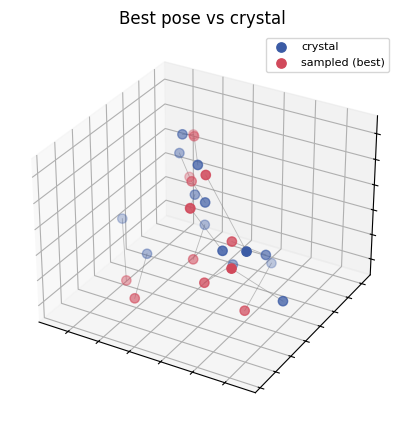

In [15]:
fig = plt.figure(figsize=(6, 5)); ax = fig.add_subplot(111, projection='3d')
viz.plot_pose_overlay(ax, best_pose_f, ligf.coords, ligf.elements); plt.show()

## 5. Takeaways

- Pose sampling → **QUBO** → `qubo_matrix_to_ising_matrix` → Kaiwu **SA** or the real **CIM**.
- The CIM is 8-bit: a `PrecisionReducer` quantizes the matrix; keep the QUBO small
  (few grid points / capped features) so the expanded matrix fits the ~1000-spin budget.
- On these dense QUBOs the CIM is **sampling-limited and high-variance** — the native
  pose appears in ~1 run of 5. **Pool a few runs** and it reliably surfaces (GPM 1.25 Å,
  FAM 1.84 Å). This is the central, honest lesson; precision changes are within the noise.
- **GPM** reads the pose as geometry (vdW grid); **FAM** reads it as chemistry — the
  pooled-best pose's hydrogen bonds match the crystal's, atom for atom.